# Modelos de confiabilidad para TEL211

Este notebook acompaña las presentaciones `02_1-teoria-confiabilidad.md` y `02_2-modelacion-e-inferencia-confiabilidad.md`. Las visualizaciones y cálculos siguen los conceptos y ejemplos desarrollados en ambas.


In [1]:
from math import exp, gamma, log
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

AZUL = "#2f6f9f"
NARANJO = "#d97706"
VERDE = "#2f855a"
ROJO = "#b91c1c"


def linspace(start, stop, count):
    if count <= 1:
        return [start]
    step = (stop - start) / (count - 1)
    return [start + i * step for i in range(count)]


## Funciones auxiliares

Estas funciones implementan directamente las fórmulas de la presentación.


In [2]:
def check_non_negative(value, name):
    if value < 0:
        raise ValueError(f"{name} debe ser no negativo")


def check_positive(value, name):
    if value <= 0:
        raise ValueError(f"{name} debe ser positivo")


def exponential_reliability(rate, time):
    check_positive(rate, "rate")
    check_non_negative(time, "time")
    return exp(-rate * time)


def exponential_cdf(rate, time):
    return 1 - exponential_reliability(rate, time)


def exponential_pdf(rate, time):
    check_positive(rate, "rate")
    check_non_negative(time, "time")
    return rate * exp(-rate * time)


def exponential_hazard(rate, time):
    check_positive(rate, "rate")
    check_non_negative(time, "time")
    return rate


def weibull_reliability(time, beta, eta):
    check_non_negative(time, "time")
    check_positive(beta, "beta")
    check_positive(eta, "eta")
    return exp(-((time / eta) ** beta))


def weibull_pdf(time, beta, eta):
    check_non_negative(time, "time")
    check_positive(beta, "beta")
    check_positive(eta, "eta")
    if time == 0 and beta < 1:
        return float("inf")
    return (beta / eta) * (time / eta) ** (beta - 1) * exp(-((time / eta) ** beta))


def weibull_hazard(time, beta, eta):
    check_non_negative(time, "time")
    check_positive(beta, "beta")
    check_positive(eta, "eta")
    if time == 0 and beta < 1:
        return float("inf")
    return (beta / eta) * (time / eta) ** (beta - 1)


def weibull_mttf(beta, eta):
    check_positive(beta, "beta")
    check_positive(eta, "eta")
    return eta * gamma(1 + 1 / beta)


def estimate_exponential_rate_complete(failure_times):
    if not failure_times:
        raise ValueError("se requiere al menos una falla")
    for time in failure_times:
        check_positive(time, "tiempo de falla")
    return len(failure_times) / sum(failure_times)


def estimate_exponential_rate_with_censoring(failure_times, censored_times):
    for time in failure_times:
        check_positive(time, "tiempo de falla")
    for time in censored_times:
        check_positive(time, "tiempo censurado")
    total_time = sum(failure_times) + sum(censored_times)
    if total_time <= 0:
        raise ValueError("el tiempo observado debe ser positivo")
    return len(failure_times) / total_time


def trapezoid_area(xs, ys):
    area = 0
    for left, right, y_left, y_right in zip(xs[:-1], xs[1:], ys[:-1], ys[1:]):
        area += (right - left) * (y_left + y_right) / 2
    return area


## Cuatro funciones, una misma variable

Sea $T\ge 0$ una variable aleatoria continua, que representa el tiempo hasta la falla.

$$
F(t)=P(T\le t),\qquad R(t)=P(T>t)=1-F(t)
$$

$$
f(t)=\frac{dF(t)}{dt},\qquad h(t)=\frac{f(t)}{R(t)}
$$

$R(t)$ es la probabilidad de completar una misión de duración $t$ sin fallar. $h(t)$ es la tasa condicional de falla para quienes ya sobrevivieron hasta $t$.


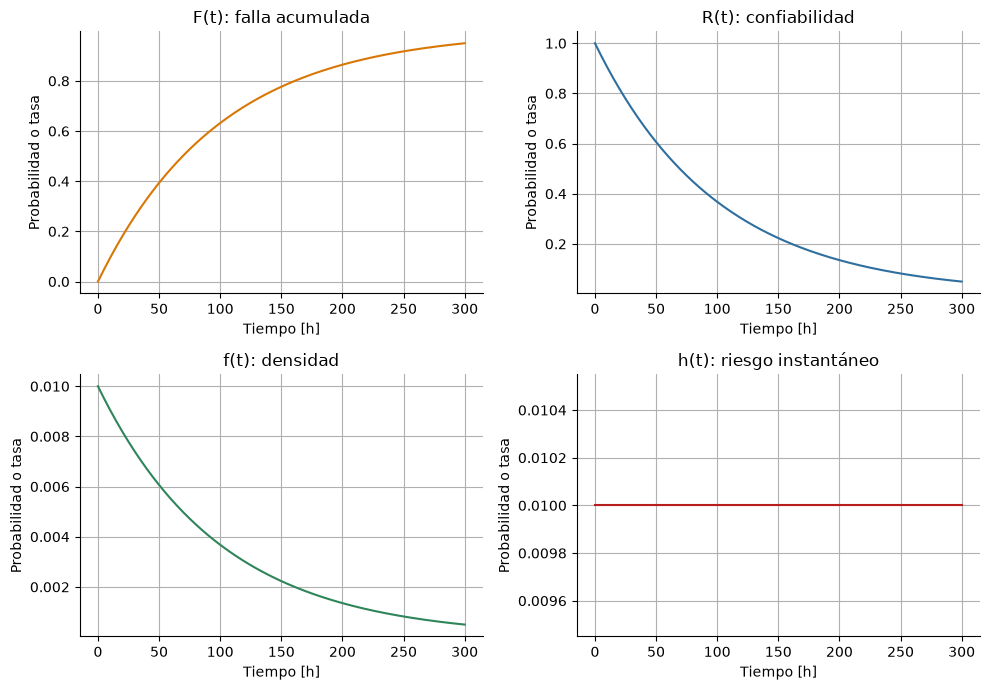

In [3]:
# Modelo exponencial para visualizar F(t), R(t), f(t) y h(t)
rate = 0.01
hours = linspace(0, 300, 301)
reliability = [exponential_reliability(rate, t) for t in hours]
cdf = [exponential_cdf(rate, t) for t in hours]
pdf = [exponential_pdf(rate, t) for t in hours]
hazard = [exponential_hazard(rate, t) for t in hours]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()
titles = [(cdf, "F(t): falla acumulada", NARANJO), (reliability, "R(t): confiabilidad", AZUL), (pdf, "f(t): densidad", VERDE), (hazard, "h(t): riesgo instantáneo", ROJO)]
for ax, (values, title, color) in zip(axes, titles):
    ax.plot(hours, values, color=color)
    ax.set_title(title)
    ax.set_xlabel("Tiempo [h]")
    ax.set_ylabel("Probabilidad o tasa")
plt.tight_layout()
plt.show()


## Confiabilidad como área restante

$$
R(t)=\int_t^\infty f(u)\,du
$$

El área a la derecha de $t$ reúne todos los tiempos de falla mayores que $t$.


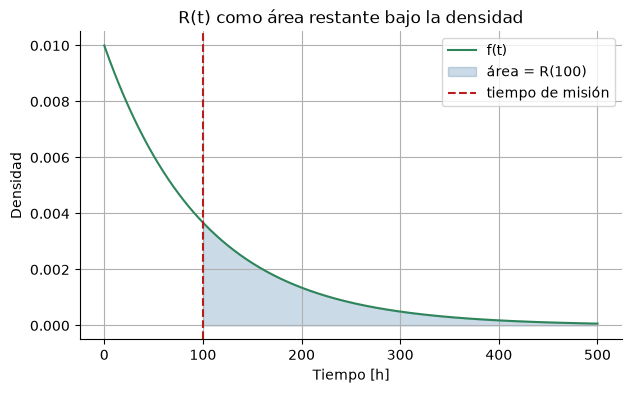

R(100 h) = 0.3679


In [4]:
# Área restante bajo f(t) para una misión de 100 h
rate = 0.01
mission_time = 100
hours = linspace(0, 500, 501)
pdf_values = [exponential_pdf(rate, t) for t in hours]
r_mission = exponential_reliability(rate, mission_time)

fig, ax = plt.subplots()
ax.plot(hours, pdf_values, color=VERDE, label="f(t)")
right_x = [t for t in hours if t >= mission_time]
right_y = [exponential_pdf(rate, t) for t in right_x]
ax.fill_between(right_x, right_y, color=AZUL, alpha=0.25, label="área = R(100)")
ax.axvline(mission_time, color=ROJO, linestyle="--", label="tiempo de misión")
ax.set_xlabel("Tiempo [h]")
ax.set_ylabel("Densidad")
ax.set_title("R(t) como área restante bajo la densidad")
ax.legend()
plt.show()
print(f"R(100 h) = {r_mission:.4f}")


## Riesgo condicional: evento y condición

$R(t)$ entrega la supervivencia desde el inicio. Para medir el riesgo después de $t$, se condiciona a que el componente llegó funcionando hasta ese tiempo.

$$
P(t<T\le t+\Delta t)=R(t)-R(t+\Delta t)
$$

$$
P(t<T\le t+\Delta t\mid T>t)=\frac{R(t)-R(t+\Delta t)}{R(t)}
$$

Al dividir por $\Delta t$ y hacer el intervalo cada vez más pequeño aparece $h(t)=f(t)/R(t)$.


In [5]:
# Probabilidad condicional de falla en un intervalo para el router
rate_router = 2e-5
t = 5000
delta_t = 1000
r_t = exponential_reliability(rate_router, t)
r_t_delta = exponential_reliability(rate_router, t + delta_t)
interval_probability = r_t - r_t_delta
conditional_probability = interval_probability / r_t
local_rate = conditional_probability / delta_t

print(f"R({t} h) = {r_t:.4f}")
print(f"R({t + delta_t} h) = {r_t_delta:.4f}")
print(f"P({t} < T <= {t + delta_t}) = {interval_probability:.4f}")
print(f"P({t} < T <= {t + delta_t} | T > {t}) = {conditional_probability:.4f}")
print(f"Probabilidad condicional por hora aproximada = {local_rate:.8f}")
print(f"Tasa exacta del modelo exponencial = {rate_router:.8f}")


R(5000 h) = 0.9048
R(6000 h) = 0.8869
P(5000 < T <= 6000) = 0.0179
P(5000 < T <= 6000 | T > 5000) = 0.0198
Probabilidad condicional por hora aproximada = 0.00001980
Tasa exacta del modelo exponencial = 0.00002000


## Del riesgo a la confiabilidad

$$
H(t)=\int_0^t h(u)\,du,\qquad R(t)=e^{-H(t)}
$$

Para el modelo exponencial, $h(t)=\lambda$ es constante, por lo que $H(t)=\lambda t$ y $R(t)=e^{-\lambda t}$.


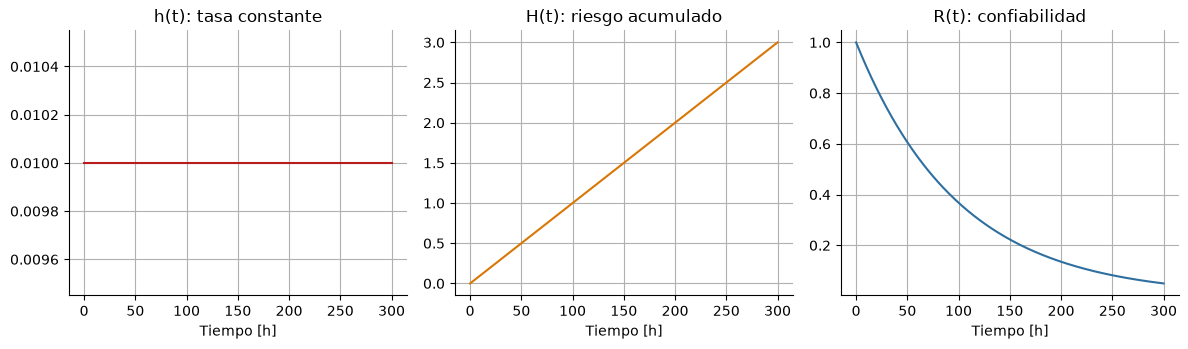

In [6]:
# Comparación visual entre riesgo constante y confiabilidad exponencial
rate = 0.01
hours = linspace(0, 300, 301)
hazard = [rate for _ in hours]
cumulative_hazard = [rate * t for t in hours]
reliability = [exp(-h) for h in cumulative_hazard]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].plot(hours, hazard, color=ROJO)
axes[0].set_title("h(t): tasa constante")
axes[1].plot(hours, cumulative_hazard, color=NARANJO)
axes[1].set_title("H(t): riesgo acumulado")
axes[2].plot(hours, reliability, color=AZUL)
axes[2].set_title("R(t): confiabilidad")
for ax in axes:
    ax.set_xlabel("Tiempo [h]")
plt.tight_layout()
plt.show()


## Ejemplo guiado: misión de un router

Un router tiene tasa de falla constante $\lambda=2\times10^{-5}\ \mathrm h^{-1}$. Para una misión de un año, $t=8760\ \mathrm h$:

$$
R(8760)=e^{-(2\times10^{-5})(8760)}\approx0.8393
$$

Por tanto, $P(T\le8760)=1-R(8760)\approx0.1607$. El resultado se refiere a un router sin reparación durante la misión.


R(8760 h) = 0.8393
P(T <= 8760 h) = 0.1607
Probabilidad de completar un año sin falla = 83.93%


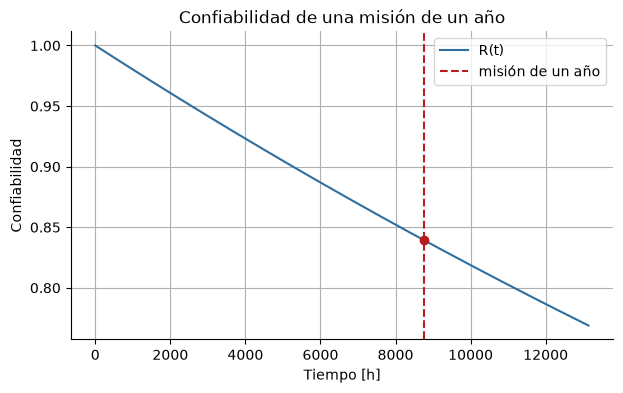

In [7]:
rate_router = 2e-5
mission_hours = 8760
r_mission = exponential_reliability(rate_router, mission_hours)
f_mission = exponential_cdf(rate_router, mission_hours)

print(f"R(8760 h) = {r_mission:.4f}")
print(f"P(T <= 8760 h) = {f_mission:.4f}")
print(f"Probabilidad de completar un año sin falla = {100 * r_mission:.2f}%")

hours = linspace(0, mission_hours * 1.5, 300)
reliability = [exponential_reliability(rate_router, t) for t in hours]
fig, ax = plt.subplots()
ax.plot(hours, reliability, color=AZUL, label="R(t)")
ax.axvline(mission_hours, color=ROJO, linestyle="--", label="misión de un año")
ax.scatter([mission_hours], [r_mission], color=ROJO, zorder=3)
ax.set_xlabel("Tiempo [h]")
ax.set_ylabel("Confiabilidad")
ax.set_title("Confiabilidad de una misión de un año")
ax.legend()
plt.show()


## La exponencial y la falta de memoria

Si $T$ es exponencial:

$$
P(T>s+t\mid T>s)=P(T>t)=e^{-\lambda t}
$$

Si el router anterior ya sobrevivió $5000\ \mathrm h$, la probabilidad de sobrevivir otras $1000\ \mathrm h$ es aproximadamente $0.9802$.


In [8]:
s = 5000
t_extra = 1000
conditional = exponential_reliability(rate_router, t_extra)
ratio = exponential_reliability(rate_router, s + t_extra) / exponential_reliability(rate_router, s)
print(f"P(T > {s + t_extra} | T > {s}) por razón = {ratio:.4f}")
print(f"P(T > {t_extra}) por falta de memoria = {conditional:.4f}")


P(T > 6000 | T > 5000) por razón = 0.9802
P(T > 1000) por falta de memoria = 0.9802


## Modelo Weibull: riesgo variable

Con forma $\beta>0$ y escala $\eta>0$:

$$
R(t)=e^{-(t/\eta)^\beta},\qquad h(t)=\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1}
$$

- $0<\beta<1$: riesgo decreciente.
- $\beta=1$: riesgo constante.
- $\beta>1$: riesgo creciente.

$\eta$ es la escala o vida característica.


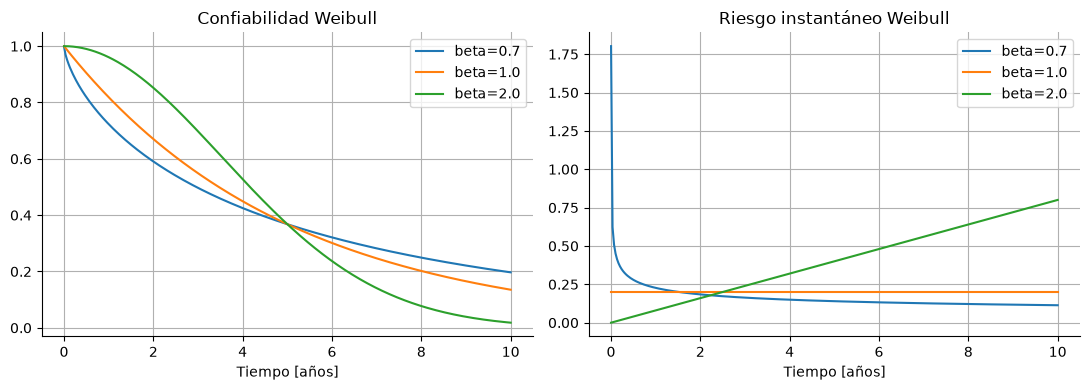

In [9]:
# Comparación del riesgo Weibull para distintas formas beta
eta = 5
betas = [0.7, 1.0, 2.0]
years = linspace(0.001, 10, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for beta in betas:
    r_values = [weibull_reliability(t, beta, eta) for t in years]
    h_values = [weibull_hazard(t, beta, eta) for t in years]
    axes[0].plot(years, r_values, label=f"beta={beta}")
    axes[1].plot(years, h_values, label=f"beta={beta}")
axes[0].set_title("Confiabilidad Weibull")
axes[1].set_title("Riesgo instantáneo Weibull")
for ax in axes:
    ax.set_xlabel("Tiempo [años]")
    ax.legend()
plt.tight_layout()
plt.show()


## Ejemplo Weibull: batería

La vida de una batería sigue un modelo Weibull con $\beta=2$ y $\eta=5\ \text{a\~nos}$.

$$
R(3)=e^{-(3/5)^2}\approx0.6977,\qquad h(3)=\frac{2}{5}\left(\frac{3}{5}\right)=0.24\ \text{a\~no}^{-1}
$$

El riesgo aumenta con la edad porque $\beta>1$.


In [10]:
beta_battery = 2
eta_battery = 5
time_battery = 3
r_battery = weibull_reliability(time_battery, beta_battery, eta_battery)
h_battery = weibull_hazard(time_battery, beta_battery, eta_battery)
print(f"R(3 años) = {r_battery:.4f}")
print(f"h(3 años) = {h_battery:.4f} por año")
print("La tasa de riesgo aumenta con la edad porque beta > 1")


R(3 años) = 0.6977
h(3 años) = 0.2400 por año
La tasa de riesgo aumenta con la edad porque beta > 1


## Tiempo medio hasta la falla (MTTF)

MTTF representa la vida media esperada antes de la primera falla de una unidad no reparable.

$$
\mathrm{MTTF}=E[T]=\int_0^\infty t f(t)\,dt=\int_0^\infty R(t)\,dt
$$

Para los modelos de la presentación: $\mathrm{MTTF}=1/\lambda$ en Exponencial y $\mathrm{MTTF}=\eta\,\Gamma(1+1/\beta)$ en Weibull.


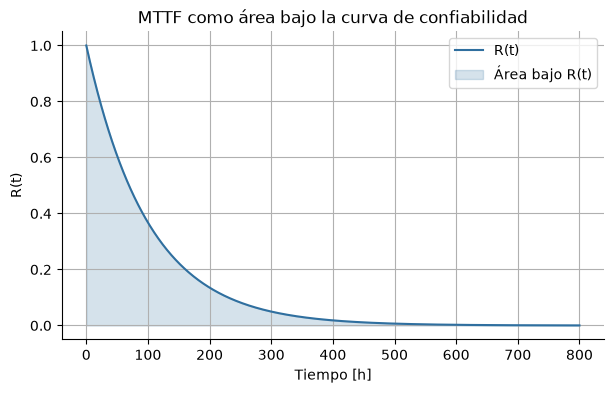

Área aproximada hasta 800 h = 99.97 h
MTTF exacto exponencial = 100.00 h


In [11]:
# Aproximación visual de MTTF como área bajo R(t)
rate = 0.01
hours = linspace(0, 800, 801)
r_values = [exponential_reliability(rate, t) for t in hours]
estimated_mttf = trapezoid_area(hours, r_values)
exact_mttf = 1 / rate
fig, ax = plt.subplots()
ax.plot(hours, r_values, color=AZUL, label="R(t)")
ax.fill_between(hours, r_values, color=AZUL, alpha=0.2, label="Área bajo R(t)")
ax.set_title("MTTF como área bajo la curva de confiabilidad")
ax.set_xlabel("Tiempo [h]")
ax.set_ylabel("R(t)")
ax.legend()
plt.show()
print(f"Área aproximada hasta 800 h = {estimated_mttf:.2f} h")
print(f"MTTF exacto exponencial = {exact_mttf:.2f} h")


## Confiabilidad no es disponibilidad

La confiabilidad de misión exige no fallar durante el intervalo estudiado. La disponibilidad pregunta si el sistema está operativo en un instante, incluso si antes falló y fue reparado.


## Estimación a partir de datos de falla

Si se observan $n$ componentes hasta fallar y se registran sus tiempos $t_1,t_2,\ldots,t_n$, para el modelo exponencial:

$$
\widehat{\lambda}=\frac{n}{\sum_{i=1}^n t_i}
$$

La estimación divide el número de fallas observadas por el tiempo total de funcionamiento observado.


## Ejemplo: prueba de módulos con censura

Se observan cinco módulos: tres fallan a $800$, $1000$ y $1200\ \mathrm h$, y dos siguen operando al cierre a $1000\ \mathrm h$. Entonces $d=3$ y $\tau=5000\ \mathrm h$:

$$
\widehat{\lambda}=\frac{3}{5000}=6\times10^{-4}\ \mathrm h^{-1},\qquad \widehat{\mathrm{MTTF}}\approx1667\ \mathrm h
$$

Las unidades que siguen funcionando aportan tiempo observado: son datos censurados.


In [12]:
failure_times = [800, 1000, 1200]
censored_times = [1000, 1000]
rate_with_censoring = estimate_exponential_rate_with_censoring(failure_times, censored_times)
mttf_with_censoring = 1 / rate_with_censoring
mission_time = 500
r_mission = exponential_reliability(rate_with_censoring, mission_time)
print(f"lambda estimada = {rate_with_censoring:.6f} 1/h")
print(f"MTTF estimado = {mttf_with_censoring:.1f} h")
print(f"R(500 h) = {r_mission:.4f}")


lambda estimada = 0.000600 1/h
MTTF estimado = 1666.7 h
R(500 h) = 0.7408


## Ejercicio de la presentación

Un módulo tiene vida exponencial con media $4000\ \mathrm h$.

1. Determinar $\lambda$.
2. Calcular $R(1000)$.
3. Calcular $P(1000<T\le1500)$.
4. Calcular $P(T>1500\mid T>1000)$.


In [13]:
mean_life = 4000
rate_module = 1 / mean_life
r_1000 = exponential_reliability(rate_module, 1000)
r_1500 = exponential_reliability(rate_module, 1500)
interval_probability = r_1000 - r_1500
conditional_probability = r_1500 / r_1000
memoryless_probability = exponential_reliability(rate_module, 500)
print(f"lambda = {rate_module:.8f} 1/h")
print(f"R(1000) = {r_1000:.4f}")
print(f"P(1000 < T <= 1500) = {interval_probability:.4f}")
print(f"P(T > 1500 | T > 1000) = {conditional_probability:.4f}")
print(f"Por falta de memoria, P(T > 500) = {memoryless_probability:.4f}")


lambda = 0.00025000 1/h
R(1000) = 0.7788
P(1000 < T <= 1500) = 0.0915
P(T > 1500 | T > 1000) = 0.8825
Por falta de memoria, P(T > 500) = 0.8825


## Comprobaciones rápidas

Antes de usar un resultado de confiabilidad, revise:

- si el evento de falla está definido,
- si el tiempo de misión está declarado,
- si las unidades de tasas y tiempos son compatibles,
- si el modelo supone riesgo constante o riesgo variable,
- si la estimación viene de datos completos o censurados,
- si hay reparación, distinguir confiabilidad de disponibilidad.


## Complementos de las presentaciones

Estas celdas reproducen cálculos sobre Poisson y Exponencial, variabilidad, Weibull y las distribuciones adicionales del anexo.


In [14]:
from math import factorial, sqrt

def poisson_pmf(rate, time, count):
    mean_count = rate * time
    return exp(-mean_count) * mean_count**count / factorial(count)

def sample_mean(values):
    return sum(values) / len(values)

def sample_variance(values):
    mean_value = sample_mean(values)
    return sum((value - mean_value)**2 for value in values) / (len(values) - 1)

def coefficient_of_variation(values):
    return sqrt(sample_variance(values)) / sample_mean(values)

def gamma_mean(shape, rate):
    return shape / rate

def gamma_coefficient_of_variation(shape):
    return 1 / sqrt(shape)

def lognormal_mean(mu, sigma):
    return exp(mu + sigma**2 / 2)

def sample_standard_deviation(values):
    return sqrt(sample_variance(values))

def weibull_coefficient_of_variation(beta):
    check_positive(beta, "beta")
    first_moment_factor = gamma(1 + 1 / beta)
    second_moment_factor = gamma(1 + 2 / beta)
    return sqrt(second_moment_factor / first_moment_factor**2 - 1)


## Proceso de Poisson y distribución Exponencial

Si las fallas siguen un proceso de Poisson con tasa constante, el tiempo entre eventos tiene distribución Exponencial con el mismo parámetro. El siguiente cálculo comprueba que ambas expresiones entregan la misma probabilidad de no observar fallas.


In [15]:
rate = 2.0
time = 0.5

probability_no_failures_poisson = poisson_pmf(rate, time, 0)
probability_survival_exponential = exponential_reliability(rate, time)

print(f"P(N({time}) = 0) = {probability_no_failures_poisson:.4f}")
print(f"R({time}) = {probability_survival_exponential:.4f}")
assert abs(probability_no_failures_poisson - probability_survival_exponential) < 1e-12


P(N(0.5) = 0) = 0.3679
R(0.5) = 0.3679


## Variabilidad y distribuciones adicionales

El promedio no basta para describir una población de tiempos de falla. El coeficiente de variación permite comparar la desviación estándar relativa entre muestras. Weibull y las distribuciones del anexo permiten representar comportamientos distintos.


In [16]:
group_a = [900, 950, 1000, 1050, 1100]
group_b = [100, 500, 1000, 1500, 1900]

for name, lifetimes in [("A", group_a), ("B", group_b)]:
    mean_value = sample_mean(lifetimes)
    standard_deviation = sample_standard_deviation(lifetimes)
    coefficient = coefficient_of_variation(lifetimes)
    print(f"Grupo {name}: media = {mean_value:.0f} h, desviación estándar = {standard_deviation:.1f} h, CV = {coefficient:.3f}")

observed_lifetimes = [200, 500, 900, 1100, 1500, 1800]
mean_lifetime = sample_mean(observed_lifetimes)
standard_deviation_lifetime = sample_standard_deviation(observed_lifetimes)
cv_lifetime = coefficient_of_variation(observed_lifetimes)
print(f"Ejemplo de tasa constante: media = {mean_lifetime:.0f} h, desviación estándar = {standard_deviation_lifetime:.0f} h, CV = {cv_lifetime:.2f}")
print(f"CV teórico de Weibull con beta=2: {weibull_coefficient_of_variation(2):.3f}")

alpha = 4
gamma_mean_time = 10
rate_gamma = alpha / gamma_mean_time
print(f"Erlang: alpha = {alpha}, lambda = {rate_gamma:.1f} 1/h, CV = {gamma_coefficient_of_variation(alpha):.1f}")

lognormal_median = 10000
lognormal_p90 = 19000
lognormal_mu = log(lognormal_median)
lognormal_sigma = (log(lognormal_p90) - log(lognormal_median)) / 1.2816
print(f"Lognormal: mu = {lognormal_mu:.3f}, sigma = {lognormal_sigma:.3f}, media = {lognormal_mean(lognormal_mu, lognormal_sigma):.0f} h")

uniform_a, uniform_b = 8, 12
uniform_mean = (uniform_a + uniform_b) / 2
uniform_probability_at_10 = (10 - uniform_a) / (uniform_b - uniform_a)
print(f"Uniforme: intervalo = [{uniform_a}, {uniform_b}] h, media = {uniform_mean:.0f} h, P(T <= 10) = {uniform_probability_at_10:.1f}")

latencies = [95, 100, 105]
print(f"Normal: media = {sample_mean(latencies):.0f} ms, desviación estándar = {sample_standard_deviation(latencies):.0f} ms")


Grupo A: media = 1000 h, desviación estándar = 79.1 h, CV = 0.079
Grupo B: media = 1000 h, desviación estándar = 728.0 h, CV = 0.728
Ejemplo de tasa constante: media = 1000 h, desviación estándar = 600 h, CV = 0.60
CV teórico de Weibull con beta=2: 0.523
Erlang: alpha = 4, lambda = 0.4 1/h, CV = 0.5
Lognormal: mu = 9.210, sigma = 0.501, media = 11336 h
Uniforme: intervalo = [8, 12] h, media = 10 h, P(T <= 10) = 0.5
Normal: media = 100 ms, desviación estándar = 5 ms


## Ejercicio

Un servicio registra llegadas de alarmas a tasa constante $\nu=4\ \mathrm h^{-1}$. En una prueba independiente de componentes, se observan $d=5$ fallas durante $\tau=2500\ \mathrm h$.

1. Calcule la probabilidad de no recibir alarmas durante $15\ \mathrm{min}$.
2. Calcule la probabilidad de que la próxima alarma tarde más de $15\ \mathrm{min}$.
3. Estime la tasa de falla de un componente bajo modelo exponencial.
4. Indique dos razones por las cuales esta tasa no basta, por sí sola, para decidir un reemplazo preventivo.


In [17]:
alarm_rate = 4.0
alarm_time = 0.25
no_alarm_probability = poisson_pmf(alarm_rate, alarm_time, 0)
next_alarm_probability = exponential_reliability(alarm_rate, alarm_time)

failures = 5
total_component_time = 2500.0
rate_component = failures / total_component_time

print(f"P(N(0.25) = 0) = {no_alarm_probability:.4f}")
print(f"P(W > 0.25) = {next_alarm_probability:.4f}")
print(f"lambda estimada = {rate_component:.6f} 1/h")

assert abs(no_alarm_probability - exp(-1)) < 1e-12
assert abs(no_alarm_probability - next_alarm_probability) < 1e-12
assert abs(rate_component - 0.002) < 1e-12


P(N(0.25) = 0) = 0.3679
P(W > 0.25) = 0.3679
lambda estimada = 0.002000 1/h


## Solución e interpretación

La probabilidad de no recibir alarmas y la probabilidad de que la próxima alarma tarde más de $15\ \mathrm{min}$ coinciden porque ambas describen que no ocurrió ninguna alarma durante $0.25\ \mathrm h$.

La tasa estimada no basta, por sí sola, para decidir un reemplazo preventivo. Debemos revisar si la tasa es aproximadamente constante y si las condiciones de operación y el evento de falla son comparables. Además, la decisión depende del costo de reemplazar.
